In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 150
})


sns.set_style("whitegrid")

In [9]:
df = pd.read_csv('Data/data.csv', encoding='latin-1')
print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [11]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [12]:
df = df.dropna(subset=['CustomerID'])
df = df.dropna(subset=['Description'])
df = df[~df['InvoiceDate'].astype(str).str.startswith('C')]
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
print("Clean dataset:" , df.shape)



Clean dataset: (397884, 8)


In [13]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']
total_revenue = df['Revenue'].sum()
print(f"Total Revenue: £{total_revenue:,.2f}")

total_orders = df['InvoiceNo'].nunique()
print(f"Total Orders: {total_orders:,}")

total_customers = df['CustomerID'].nunique()
print(f"Total Customers: {total_customers:,}")

Total Revenue: £8,911,407.90
Total Orders: 18,532
Total Customers: 4,338


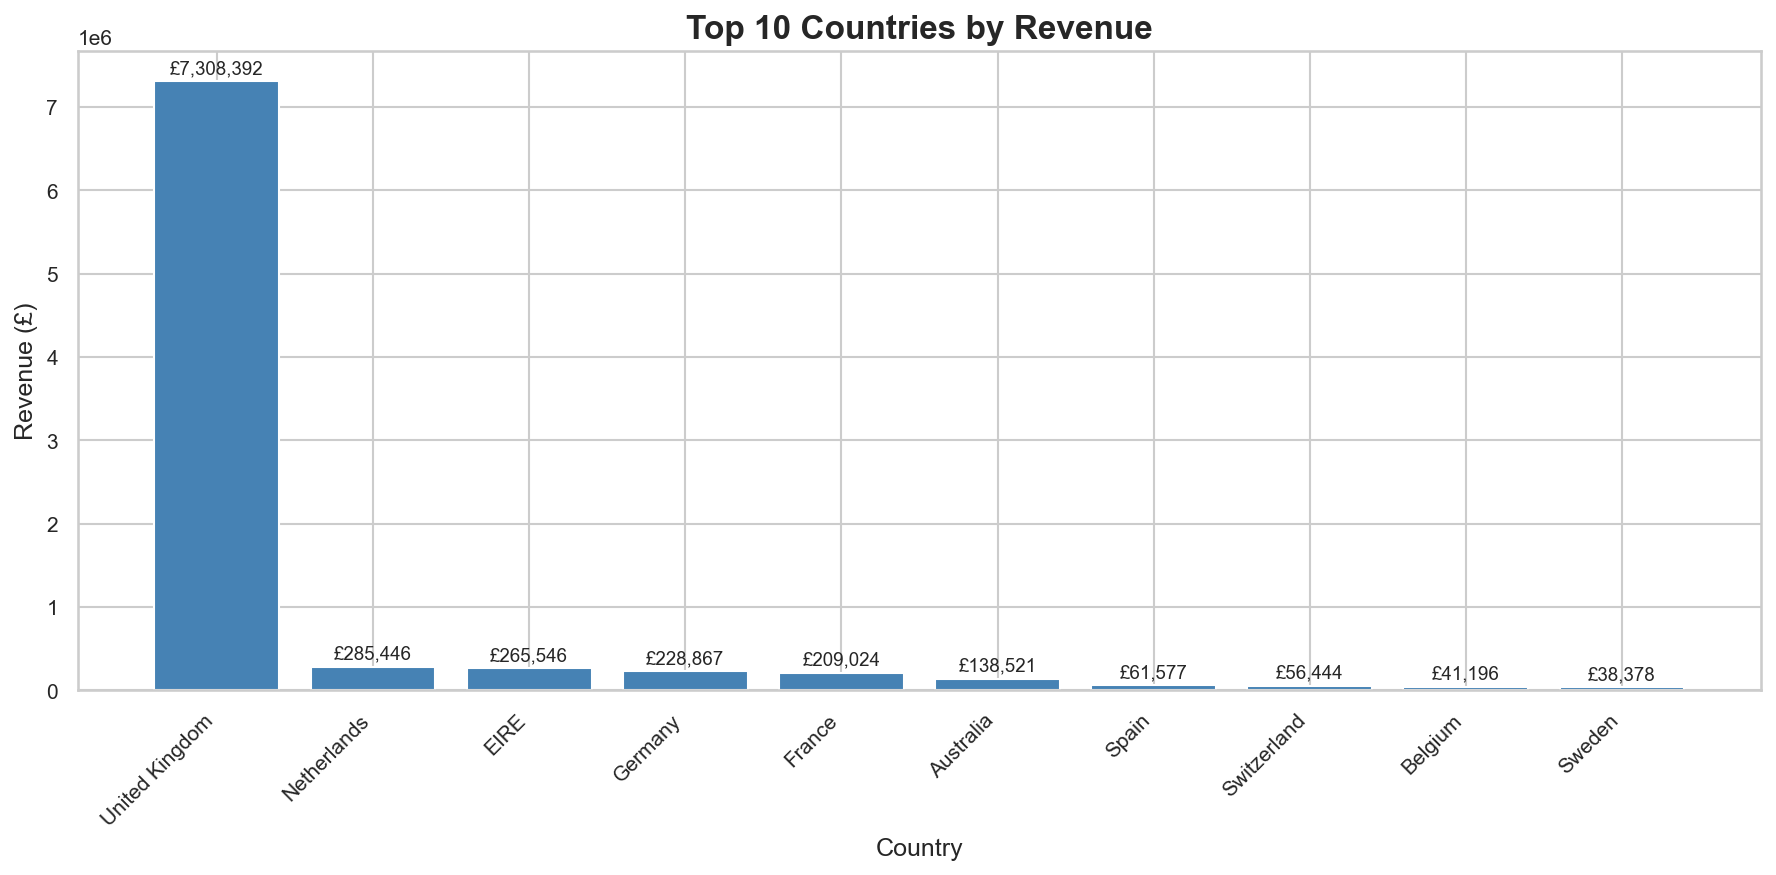

In [14]:
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots()
bars = ax.bar(country_revenue.index, country_revenue.values, color="steelblue", edgecolor='white')

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000,
            f'£{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)

ax.set_title('Top 10 Countries by Revenue')
ax.set_xlabel('Country')
ax.set_ylabel('Revenue (£)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('images/revenue_by_country.png')
plt.show()

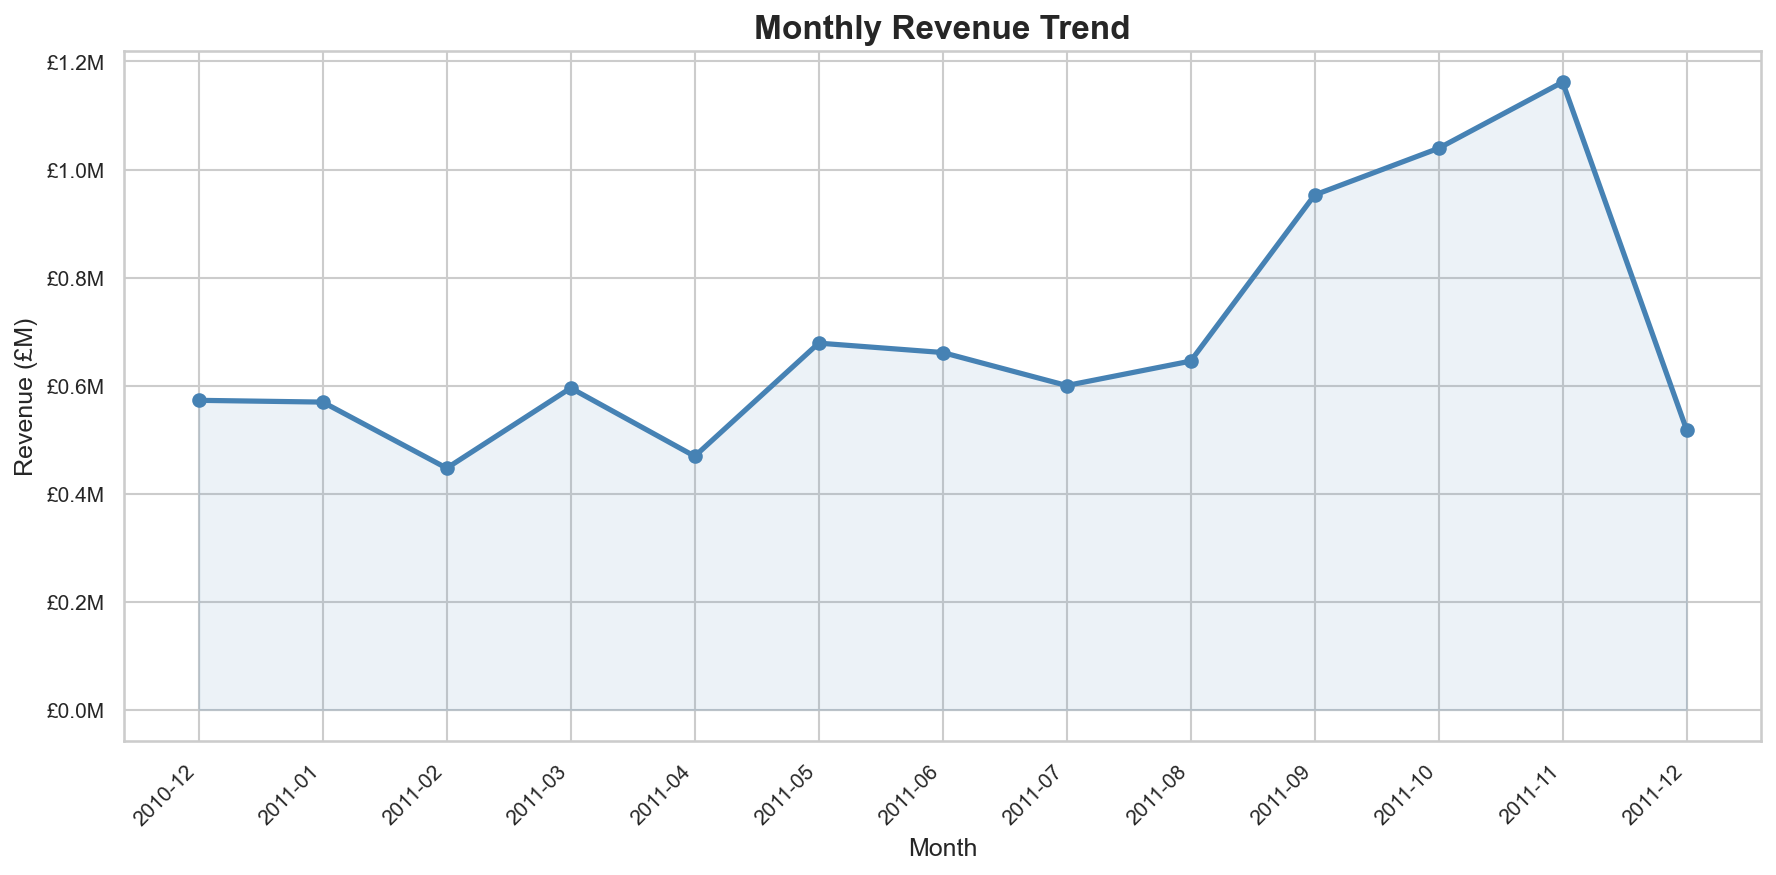

In [15]:
from matplotlib.ticker import FuncFormatter

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_revenue = df.groupby('Month')['Revenue'].sum()

fig, ax = plt.subplots()
ax.plot(monthly_revenue.index.astype(str), monthly_revenue.values,
        color='steelblue', linewidth=2.5, marker='o', markersize=6)

ax.fill_between(monthly_revenue.index.astype(str), monthly_revenue.values,
                alpha=0.1, color='steelblue')

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))

ax.set_title('Monthly Revenue Trend')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (£M)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('images/monthly_revenue.png')
plt.show()

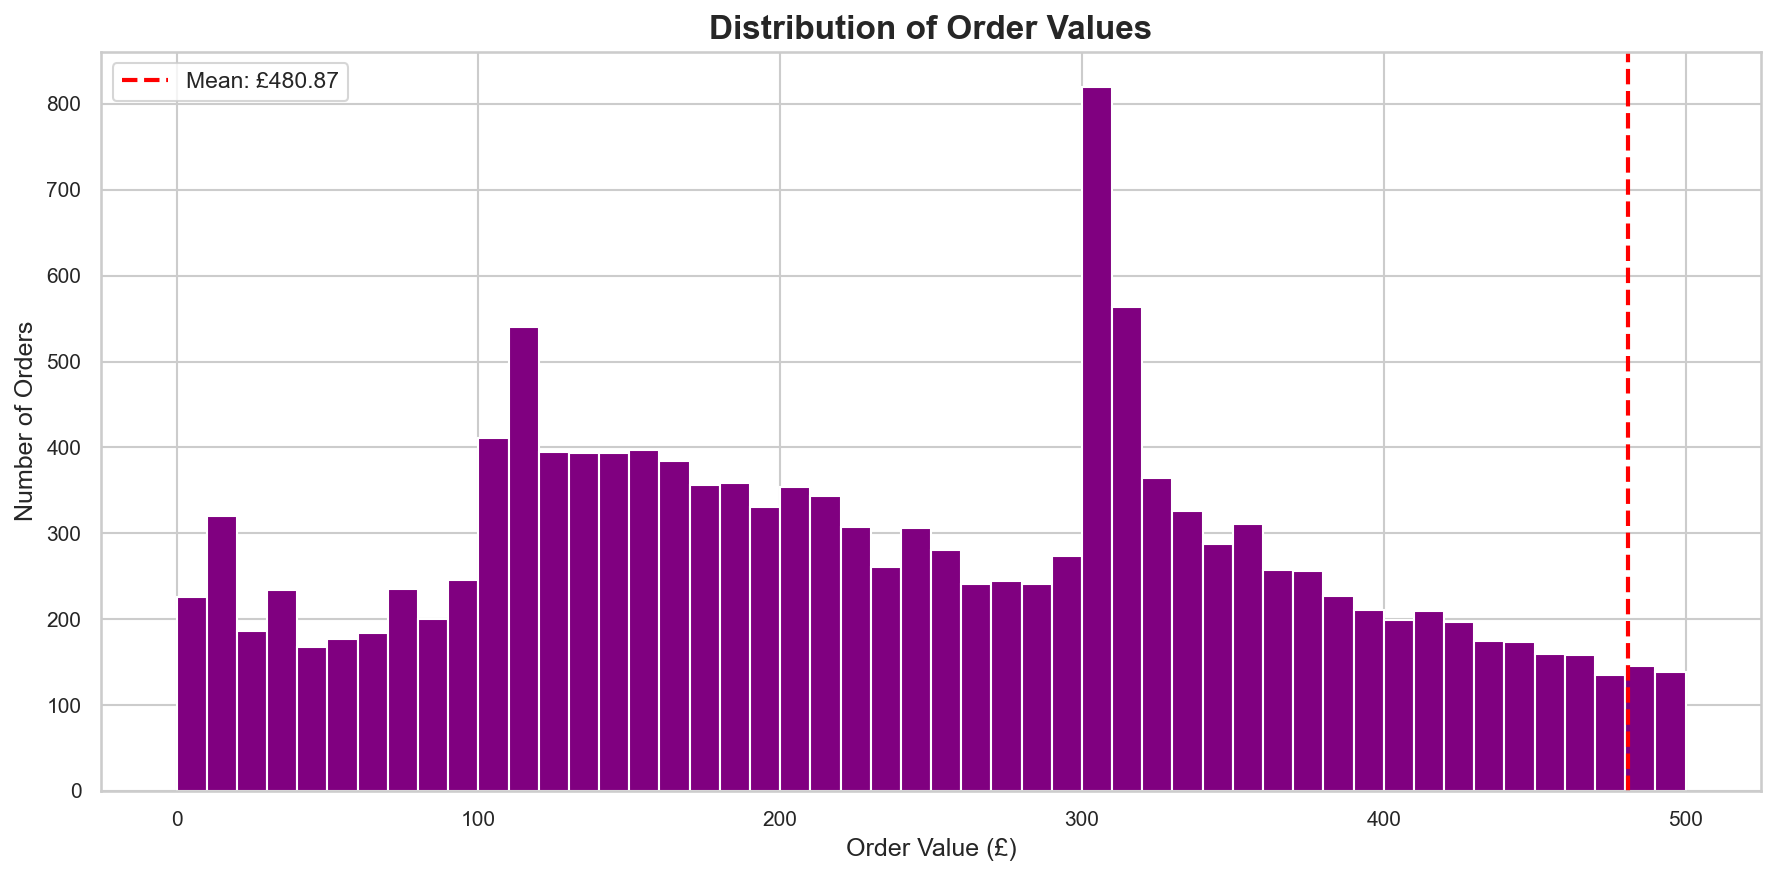

Average Order Value: £480.87
Median Order Value: £303.04


In [19]:
avg_order_value = df.groupby('InvoiceNo')['Revenue'].sum()

fig, ax = plt.subplots()
ax.hist(avg_order_value, bins=50, color="purple", edgecolor='white', range=(0, 500))

ax.set_title('Distribution of Order Values')
ax.set_xlabel('Order Value (£)')
ax.set_ylabel('Number of Orders')
ax.axvline(avg_order_value.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: £{avg_order_value.mean():.2f}')
ax.legend()
plt.tight_layout()
plt.savefig('images/order_value_dist.png')
plt.show()

print(f"Average Order Value: £{avg_order_value.mean():.2f}")
print(f"Median Order Value: £{avg_order_value.median():.2f}")